## **INDIAN AGRICULTURE CROP PRODUCTION PREDICTION**
**Author:** Data Science Pipeline
**Purpose:** Predict crop yield and production in India


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
import joblib
import pickle
import re
import os

warnings.filterwarnings('ignore')

# Set style for visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Create directories for outputs
os.makedirs('visualizations', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('predictions', exist_ok=True)

print("="*80)
print("INDIAN AGRICULTURE CROP PRODUCTION PREDICTION")
print("="*80)


INDIAN AGRICULTURE CROP PRODUCTION PREDICTION


In [2]:
# ============================================
# STEP 1: UNDERSTAND THE DATA & DEFINE PROBLEM
# ============================================
print("\n" + "="*80)
print("STEP 1: UNDERSTANDING THE DATA & DEFINING PROBLEM")
print("="*80)

print("""
PROBLEM DEFINITION:
-------------------
Goal: Predict agricultural crop production and yield in India

Target Variables:
1. Yield (Quintals/Hectare) - Regression problem
2. Production (Million Tons) - Time series regression

Input Features:
- Crop type
- State/Region
- Cost of cultivation (A2+FL and C2)
- Cost of production
- Historical yield data
- Area under cultivation
- Seasonal factors
- Variety information

Success Metrics:
- R² Score (Coefficient of Determination)
- Mean Absolute Error (MAE)
- Root Mean Square Error (RMSE)
""")




STEP 1: UNDERSTANDING THE DATA & DEFINING PROBLEM

PROBLEM DEFINITION:
-------------------
Goal: Predict agricultural crop production and yield in India

Target Variables:
1. Yield (Quintals/Hectare) - Regression problem
2. Production (Million Tons) - Time series regression

Input Features:
- Crop type
- State/Region
- Cost of cultivation (A2+FL and C2)
- Cost of production
- Historical yield data
- Area under cultivation
- Seasonal factors
- Variety information

Success Metrics:
- R² Score (Coefficient of Determination)
- Mean Absolute Error (MAE)
- Root Mean Square Error (RMSE)



In [3]:
# ============================================
# STEP 2: LOAD & INSPECT DATA
# ============================================
print("\n" + "="*80)
print("STEP 2: LOADING & INSPECTING DATA")
print("="*80)

# Load all files
try:
    df1 = pd.read_csv('datafile (1).csv')
    df2 = pd.read_csv('datafile (2).csv')
    df3 = pd.read_csv('datafile (3).csv')
    df_index = pd.read_csv('datafile.csv')
    df_produce = pd.read_csv('produce.csv')
    print("✅ All files loaded successfully!")
except FileNotFoundError as e:
    print(f"❌ Error loading files: {e}")
    print("Please ensure all CSV files are in the current directory")
    exit(1)

print(f"\nDataset shapes:")
print(f"datafile (1).csv: {df1.shape}")
print(f"datafile (2).csv: {df2.shape}")
print(f"datafile (3).csv: {df3.shape}")
print(f"datafile.csv: {df_index.shape}")
print(f"produce.csv: {df_produce.shape}")




STEP 2: LOADING & INSPECTING DATA
✅ All files loaded successfully!

Dataset shapes:
datafile (1).csv: (49, 6)
datafile (2).csv: (55, 16)
datafile (3).csv: (78, 5)
datafile.csv: (13, 9)
produce.csv: (429, 25)


In [4]:
# ============================================
# STEP 3: CLEAN EACH DATASET
# ============================================
print("\n" + "="*80)
print("STEP 3: CLEANING DATASETS")
print("="*80)

# 3.1 Clean datafile (1).csv - Cost & Yield Data
print("\n3.1 Cleaning cost & yield data...")
df1.columns = df1.columns.str.strip()

# Normalize raw column names and map them to clean feature names.
rename_map = {}
for col in df1.columns:
    normalized = col.lower().replace('`', '').replace('(', '').replace(')', '').replace('/', '_per_').strip()
    if 'crop' in normalized and 'production' not in normalized:
        rename_map[col] = 'crop'
    elif 'state' in normalized:
        rename_map[col] = 'state'
    elif 'cost of cultivation' in normalized and 'a2+fl' in normalized:
        rename_map[col] = 'cost_cultivation_A2_FL'
    elif 'cost of cultivation' in normalized and 'c2' in normalized:
        rename_map[col] = 'cost_cultivation_C2'
    elif 'cost of production' in normalized:
        rename_map[col] = 'cost_production_C2'
    elif 'yield' in normalized:
        rename_map[col] = 'yield_quintal_per_hectare'
    else:
        rename_map[col] = normalized.replace(' ', '_')

df1.rename(columns=rename_map, inplace=True)

# Convert numeric columns
numeric_cols = ['cost_cultivation_A2_FL', 'cost_cultivation_C2', 'cost_production_C2', 'yield_quintal_per_hectare']
for col in numeric_cols:
    df1[col] = pd.to_numeric(df1[col], errors='coerce')
df1.dropna(subset=['yield_quintal_per_hectare'], inplace=True)
print(f"   ✅ Cleaned shape: {df1.shape}")

# 3.2 Clean datafile (2).csv - Time Series Data
print("\n3.2 Cleaning time series data...")
df2.columns = df2.columns.str.strip().str.replace(' ', '_').str.replace('-', '_')
df2.rename(columns={df2.columns[0]: 'crop'}, inplace=True)

# Melt from wide to long format
df2_long = pd.melt(df2, id_vars=['crop'], var_name='year_metric', value_name='value')
df2_long[['metric', 'year']] = df2_long['year_metric'].str.extract(r'(Production|Area|Yield)_(\d{4}_\d{2})')
df2_long.dropna(subset=['metric', 'year'], inplace=True)
df2_long['year'] = df2_long['year'].str.split('_').str[0].astype(int)
df2_long['value'] = pd.to_numeric(df2_long['value'], errors='coerce')

# Pivot to have separate columns
df2_clean = df2_long.pivot_table(index=['crop', 'year'], columns='metric', values='value').reset_index()
df2_clean.columns.name = None
df2_clean.rename(columns={'Area': 'area_million_ha', 'Production': 'production_million_tons', 'Yield': 'yield_kg_per_ha'}, inplace=True)
print(f"   ✅ Cleaned shape: {df2_clean.shape}")

# 3.3 Clean datafile (3).csv - Variety Data
print("\n3.3 Cleaning variety data...")
df3.columns = df3.columns.str.strip().str.replace(' ', '_')
df3.rename(columns={
    'Crop': 'crop',
    'Variety': 'variety',
    'Season_per_duration_in_days': 'season_duration_days',
    'Recommended_Zone': 'recommended_zone'
}, inplace=True)

# Extract numeric duration
def extract_days(duration_str):
    if pd.isna(duration_str):
        return None
    numbers = re.findall(r'\d+', str(duration_str))
    if numbers:
        return sum([int(n) for n in numbers]) / len(numbers)
    return None

df3['Season/_duration_in_days'] = df3['Season/_duration_in_days'].apply(extract_days)
df3.rename(columns={'Season/_duration_in_days': 'season_duration_days'}, inplace=True)
df3_clean = df3.drop_duplicates(subset=['crop', 'variety'], keep='first')
print(f"   ✅ Cleaned shape: {df3_clean.shape}")

# 3.4 Clean datafile.csv - Index Data
print("\n3.4 Cleaning index data...")
df_index.columns = df_index.columns.str.strip().str.replace(' ', '_')
df_index.rename(columns={df_index.columns[0]: 'crop'}, inplace=True)
df_index_long = pd.melt(df_index, id_vars=['crop'], var_name='year', value_name='index_value')
df_index_long['year'] = df_index_long['year'].str.split('-').str[0].astype(int)
df_index_long['index_value'] = pd.to_numeric(df_index_long['index_value'], errors='coerce')
df_index_clean = df_index_long.dropna()
print(f"   ✅ Cleaned shape: {df_index_clean.shape}")

# 3.5 Clean produce.csv - Annual Production
print("\n3.5 Cleaning annual production data...")
df_produce.rename(columns={df_produce.columns[0]: 'particulars'}, inplace=True)
year_columns = [col for col in df_produce.columns if col != 'particulars']
year_mapping = {}
for col in year_columns:
    match = re.search(r'(\d{4})', str(col))
    if match:
        year_mapping[col] = int(match.group(1))
df_produce.rename(columns=year_mapping, inplace=True)
df_produce_long = pd.melt(df_produce, id_vars=['particulars'], var_name='year', value_name='production_value')
df_produce_long['year'] = pd.to_numeric(df_produce_long['year'], errors='coerce')
df_produce_long['production_value'] = pd.to_numeric(df_produce_long['production_value'], errors='coerce')
df_produce_clean = df_produce_long.dropna()
print(f"   ✅ Cleaned shape: {df_produce_clean.shape}")

print("\n✅ Step 3 Completed: All datasets cleaned!")



STEP 3: CLEANING DATASETS

3.1 Cleaning cost & yield data...
   ✅ Cleaned shape: (49, 6)

3.2 Cleaning time series data...
   ✅ Cleaned shape: (275, 5)

3.3 Cleaning variety data...
   ✅ Cleaned shape: (78, 5)

3.4 Cleaning index data...
   ✅ Cleaned shape: (96, 3)

3.5 Cleaning annual production data...
   ✅ Cleaned shape: (4272, 3)

✅ Step 3 Completed: All datasets cleaned!


In [5]:
# ============================================
# STEP 4: MERGE DATASETS INTO MASTER TABLES
# ============================================
print("\n" + "="*80)
print("STEP 4: CREATING MASTER TABLES")
print("="*80)

# 4.1 Create Yield Prediction Master Table
print("\n4.1 Creating Yield Prediction Master Table...")
master_yield = df1.copy()

# Add region classification
def assign_region(state):
    north = ['Punjab', 'Haryana', 'Uttar Pradesh', 'Uttarakhand', 'Delhi']
    south = ['Karnataka', 'Tamil Nadu', 'Kerala', 'Andhra Pradesh']
    east = ['West Bengal', 'Bihar', 'Odisha', 'Jharkhand', 'Assam']
    west = ['Maharashtra', 'Gujarat', 'Rajasthan', 'Goa']
    central = ['Madhya Pradesh', 'Chhattisgarh']
    
    if state in north: return 'North'
    elif state in south: return 'South'
    elif state in east: return 'East'
    elif state in west: return 'West'
    elif state in central: return 'Central'
    else: return 'Other'

master_yield['region'] = master_yield['state'].apply(assign_region)

# Add variety summary
variety_summary = df3_clean.groupby('crop')['season_duration_days'].mean().reset_index()
master_yield = master_yield.merge(variety_summary, on='crop', how='left')

# Add time series averages
timeseries_avg = df2_clean.groupby('crop').agg({
    'yield_kg_per_ha': 'mean',
    'area_million_ha': 'mean',
    'production_million_tons': 'mean'
}).reset_index()
master_yield = master_yield.merge(timeseries_avg, on='crop', how='left')

# Add engineered features
master_yield['cost_efficiency'] = master_yield['yield_quintal_per_hectare'] / master_yield['cost_cultivation_C2']
master_yield['profitability_index'] = master_yield['yield_quintal_per_hectare'] / master_yield['cost_production_C2']
master_yield['profitability_index'] = master_yield['yield_quintal_per_hectare'] / master_yield['cost_production_C2']

print(f"   ✅ Yield master table: {master_yield.shape[0]} rows, {master_yield.shape[1]} columns")

# 4.2 Create Production Prediction Master Table (Time Series)
print("\n4.2 Creating Production Prediction Master Table...")
master_production = df2_clean.copy()

# Add cost data by crop
cost_by_crop = df1.groupby('crop')[['cost_cultivation_C2', 'cost_production_C2']].mean().reset_index()
master_production = master_production.merge(cost_by_crop, on='crop', how='left')

# Create lag features
for crop_name in master_production['crop'].unique():
    mask = master_production['crop'] == crop_name
    crop_data = master_production.loc[mask].sort_values('year')
    for lag in [1, 2]:
        master_production.loc[mask, f'production_lag_{lag}'] = crop_data['production_million_tons'].shift(lag)
    master_production.loc[mask, 'production_rolling_3'] = crop_data['production_million_tons'].rolling(3, min_periods=1).mean()

# Create target (next year's production)
master_production = master_production.sort_values(['crop', 'year'])
master_production['production_next_year'] = master_production.groupby('crop')['production_million_tons'].shift(-1)
master_production = master_production.dropna(subset=['production_next_year'])

print(f"   ✅ Production master table: {master_production.shape[0]} rows, {master_production.shape[1]} columns")

# Save master tables
master_yield.to_csv('master_table_yield_prediction.csv', index=False)
master_production.to_csv('master_table_production_prediction.csv', index=False)
print("\n✅ Step 4 Completed: Master tables saved!")

print(f"   ✅ Yield master table: {master_yield.shape[0]} rows, {master_yield.shape[1]} columns")

# 4.2 Create Production Prediction Master Table (Time Series)
print("\n4.2 Creating Production Prediction Master Table...")
master_production = df2_clean.copy()

# Add cost data by crop
cost_by_crop = df1.groupby('crop')[['cost_cultivation_C2', 'cost_production_C2']].mean().reset_index()
master_production = master_production.merge(cost_by_crop, on='crop', how='left')

# Create lag features
for crop_name in master_production['crop'].unique():
    mask = master_production['crop'] == crop_name
    crop_data = master_production.loc[mask].sort_values('year')
    for lag in [1, 2]:
        master_production.loc[mask, f'production_lag_{lag}'] = crop_data['production_million_tons'].shift(lag)
    master_production.loc[mask, 'production_rolling_3'] = crop_data['production_million_tons'].rolling(3, min_periods=1).mean()

# Create target (next year's production)
master_production = master_production.sort_values(['crop', 'year'])
master_production['production_next_year'] = master_production.groupby('crop')['production_million_tons'].shift(-1)
master_production = master_production.dropna(subset=['production_next_year'])

print(f"   ✅ Production master table: {master_production.shape[0]} rows, {master_production.shape[1]} columns")

# Save master tables
master_yield.to_csv('master_table_yield_prediction.csv', index=False)
master_production.to_csv('master_table_production_prediction.csv', index=False)
print("\n✅ Step 4 Completed: Master tables saved!")




STEP 4: CREATING MASTER TABLES

4.1 Creating Yield Prediction Master Table...
   ✅ Yield master table: 49 rows, 13 columns

4.2 Creating Production Prediction Master Table...
   ✅ Production master table: 220 rows, 11 columns

✅ Step 4 Completed: Master tables saved!
   ✅ Yield master table: 49 rows, 13 columns

4.2 Creating Production Prediction Master Table...
   ✅ Production master table: 220 rows, 11 columns

✅ Step 4 Completed: Master tables saved!



STEP 5: EXPLORATORY DATA ANALYSIS


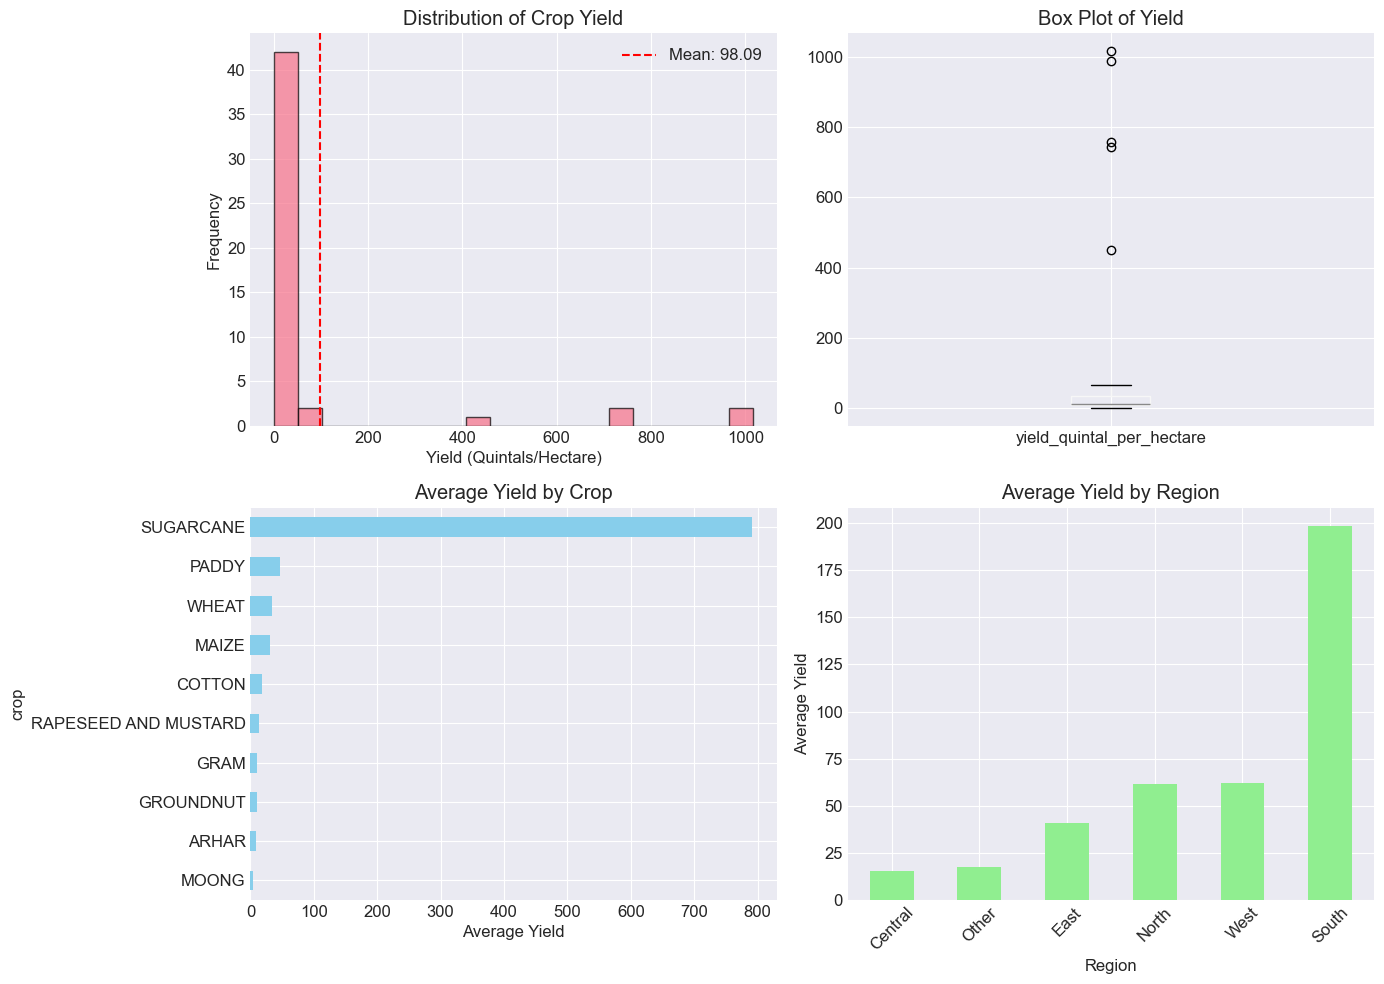

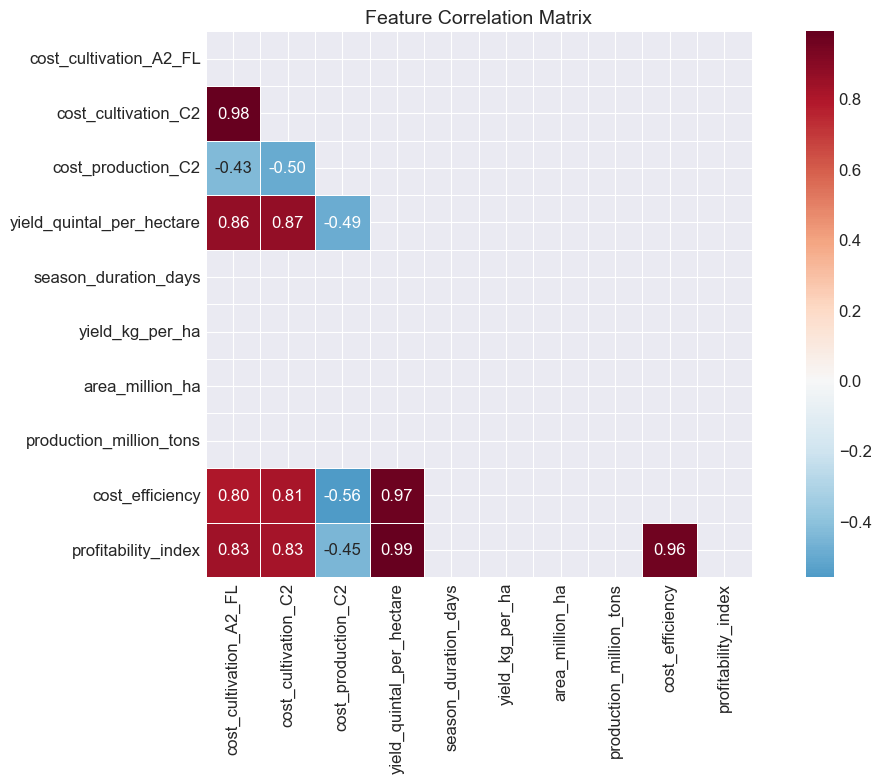

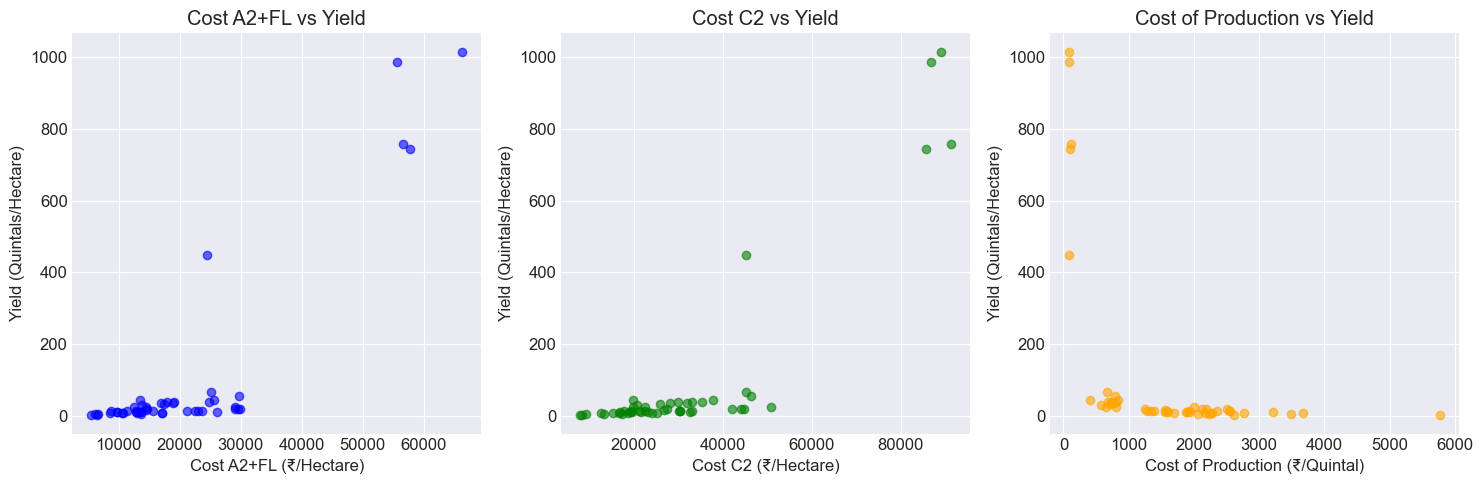

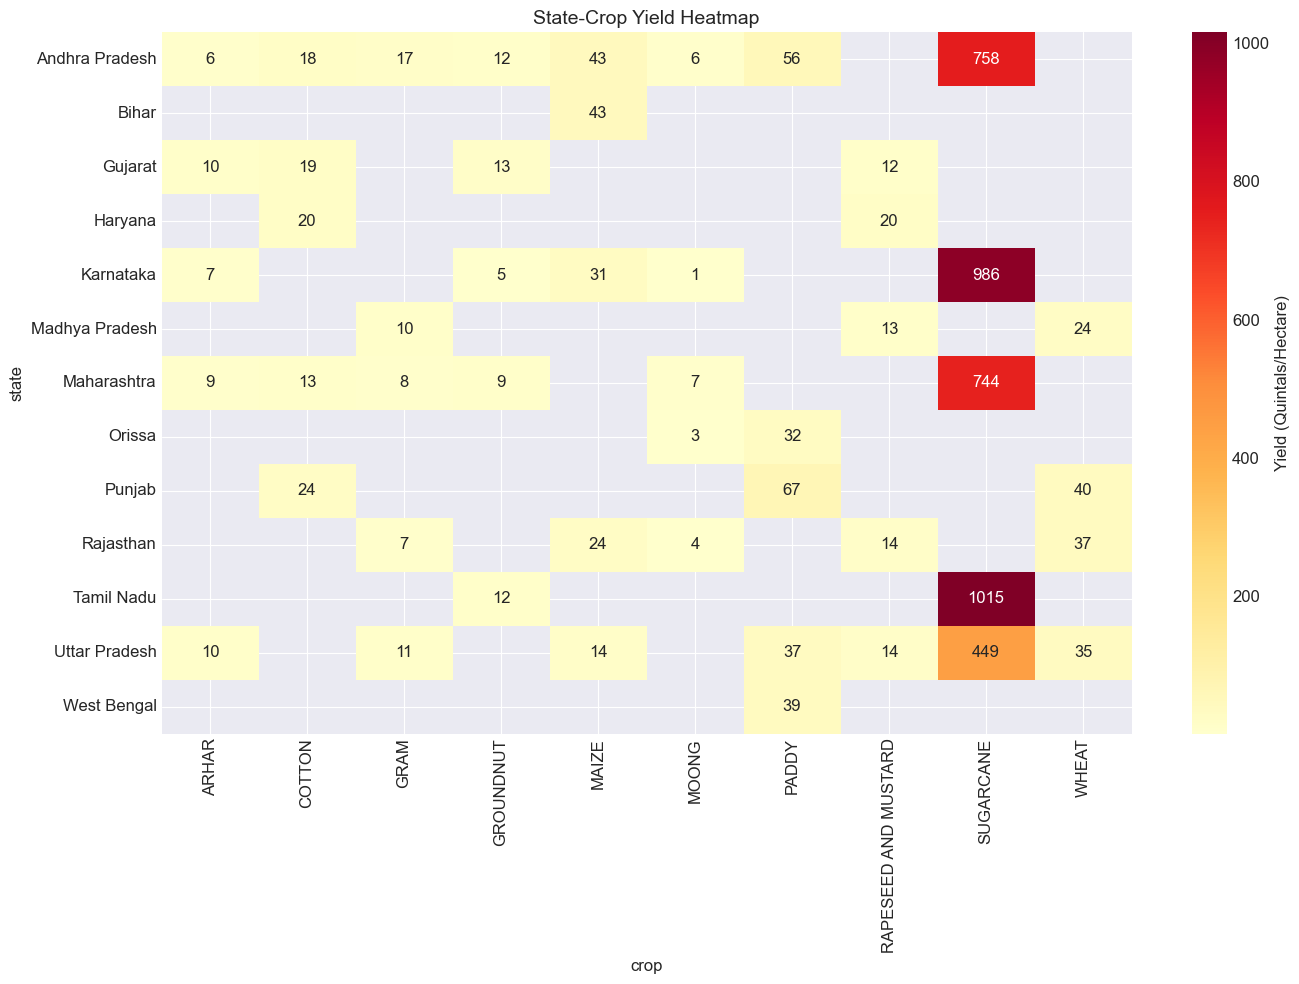


✅ Step 5 Completed: EDA visualizations saved to 'visualizations' folder


In [6]:
# ============================================
# STEP 5: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================
print("\n" + "="*80)
print("STEP 5: EXPLORATORY DATA ANALYSIS")
print("="*80)

# 5.1 Target Variable Distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(master_yield['yield_quintal_per_hectare'], bins=20, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Yield (Quintals/Hectare)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Crop Yield')
axes[0, 0].axvline(master_yield['yield_quintal_per_hectare'].mean(), color='red', linestyle='--', 
                   label=f"Mean: {master_yield['yield_quintal_per_hectare'].mean():.2f}")
axes[0, 0].legend()

master_yield.boxplot(column='yield_quintal_per_hectare', ax=axes[0, 1])
axes[0, 1].set_title('Box Plot of Yield')

# Yield by crop
crop_yield = master_yield.groupby('crop')['yield_quintal_per_hectare'].mean().sort_values()
crop_yield.plot(kind='barh', ax=axes[1, 0], color='skyblue')
axes[1, 0].set_xlabel('Average Yield')
axes[1, 0].set_title('Average Yield by Crop')

# Yield by region
region_yield = master_yield.groupby('region')['yield_quintal_per_hectare'].mean().sort_values()
region_yield.plot(kind='bar', ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_xlabel('Region')
axes[1, 1].set_ylabel('Average Yield')
axes[1, 1].set_title('Average Yield by Region')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('visualizations/eda_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 5.2 Correlation Analysis
numeric_cols = master_yield.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = master_yield[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('visualizations/eda_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 5.3 Cost vs Yield Analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(master_yield['cost_cultivation_A2_FL'], master_yield['yield_quintal_per_hectare'], alpha=0.6, color='blue')
axes[0].set_xlabel('Cost A2+FL (₹/Hectare)')
axes[0].set_ylabel('Yield (Quintals/Hectare)')
axes[0].set_title('Cost A2+FL vs Yield')

axes[1].scatter(master_yield['cost_cultivation_C2'], master_yield['yield_quintal_per_hectare'], alpha=0.6, color='green')
axes[1].set_xlabel('Cost C2 (₹/Hectare)')
axes[1].set_ylabel('Yield (Quintals/Hectare)')
axes[1].set_title('Cost C2 vs Yield')

axes[2].scatter(master_yield['cost_production_C2'], master_yield['yield_quintal_per_hectare'], alpha=0.6, color='orange')
axes[2].set_xlabel('Cost of Production (₹/Quintal)')
axes[2].set_ylabel('Yield (Quintals/Hectare)')
axes[2].set_title('Cost of Production vs Yield')

plt.tight_layout()
plt.savefig('visualizations/eda_cost_vs_yield.png', dpi=300, bbox_inches='tight')
plt.show()

# 5.4 State-Crop Heatmap
state_crop_pivot = master_yield.pivot_table(index='state', columns='crop', values='yield_quintal_per_hectare', aggfunc='mean')
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(state_crop_pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, 
            cbar_kws={'label': 'Yield (Quintals/Hectare)'})
ax.set_title('State-Crop Yield Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('visualizations/eda_state_crop_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Step 5 Completed: EDA visualizations saved to 'visualizations' folder")



In [7]:
# ============================================
# STEP 6: FEATURE ENGINEERING
# ============================================
print("\n" + "="*80)
print("STEP 6: FEATURE ENGINEERING")
print("="*80)

# 6.1 Encode categorical variables
print("\n6.1 Encoding categorical variables...")
le_crop = LabelEncoder()
le_state = LabelEncoder()
le_region = LabelEncoder()

master_yield['crop_encoded'] = le_crop.fit_transform(master_yield['crop'])
master_yield['state_encoded'] = le_state.fit_transform(master_yield['state'])
master_yield['region_encoded'] = le_region.fit_transform(master_yield['region'])

# 6.2 Create interaction features
print("6.2 Creating interaction features...")
master_yield['cost_area_interaction'] = master_yield['cost_cultivation_C2'] * master_yield['area_million_ha']
master_yield['yield_cost_ratio'] = master_yield['yield_quintal_per_hectare'] / master_yield['cost_cultivation_C2']
master_yield['production_efficiency'] = master_yield['production_million_tons'] / master_yield['area_million_ha']

# 6.3 Create polynomial features for production data
print("6.3 Creating time series features...")
master_production['year_squared'] = master_production['year'] ** 2
master_production['year_cubic'] = master_production['year'] ** 3
master_production['production_growth'] = master_production.groupby('crop')['production_million_tons'].pct_change() * 100

# 6.4 Handle missing values
print("6.4 Handling missing values...")
master_yield.fillna(master_yield.median(numeric_only=True), inplace=True)
master_production.fillna(master_production.median(numeric_only=True), inplace=True)

print(f"   ✅ Final yield features: {master_yield.shape[1]} columns")
print(f"   ✅ Final production features: {master_production.shape[1]} columns")

# Save feature-engineered data
master_yield.to_csv('master_table_with_features.csv', index=False)
master_production.to_csv('production_with_features.csv', index=False)

print("\n✅ Step 6 Completed: Feature engineering done!")




STEP 6: FEATURE ENGINEERING

6.1 Encoding categorical variables...
6.2 Creating interaction features...
6.3 Creating time series features...
6.4 Handling missing values...
   ✅ Final yield features: 19 columns
   ✅ Final production features: 14 columns

✅ Step 6 Completed: Feature engineering done!


In [8]:
# ============================================
# STEP 7: PREPARE DATA FOR MODELING
# ============================================
print("\n" + "="*80)
print("STEP 7: PREPARING DATA FOR MODELING")
print("="*80)

# 7.1 Prepare Yield Prediction Dataset
print("\n7.1 Preparing yield prediction dataset...")
feature_cols_yield = ['cost_cultivation_A2_FL', 'cost_cultivation_C2', 'cost_production_C2',
                      'crop_encoded', 'state_encoded', 'region_encoded', 'season_duration_days',
                      'yield_kg_per_ha', 'area_million_ha', 'production_million_tons',
                      'cost_efficiency', 'profitability_index', 'cost_area_interaction',
                      'yield_cost_ratio', 'production_efficiency']

X_yield = master_yield[['cost_cultivation_A2_FL', 'cost_cultivation_C2', 'cost_production_C2',
                        'crop_encoded', 'state_encoded', 'region_encoded', 'season_duration_days',
                        'yield_kg_per_ha', 'area_million_ha', 'production_million_tons',
                        'cost_efficiency', 'profitability_index', 'cost_area_interaction',
                        'yield_cost_ratio', 'production_efficiency']]
y_yield = master_yield['yield_quintal_per_hectare']

# Scale features
scaler_yield = StandardScaler()
X_yield_scaled = scaler_yield.fit_transform(X_yield)

# Split data
X_yield_train, X_yield_test, y_yield_train, y_yield_test = train_test_split(
    X_yield_scaled, y_yield, test_size=0.2, random_state=42
)

print(f"   ✅ Training set: {X_yield_train.shape[0]} samples")
print(f"   ✅ Test set: {X_yield_test.shape[0]} samples")

# 7.2 Prepare Production Prediction Dataset
print("\n7.2 Preparing production prediction dataset...")
feature_cols_prod = ['year', 'year_squared', 'year_cubic', 'area_million_ha', 'yield_kg_per_ha',
                     'cost_cultivation_C2', 'cost_production_C2', 'production_lag_1', 
                     'production_lag_2', 'production_rolling_3', 'production_growth']

# Encode crop for production data
le_crop_prod = LabelEncoder()
master_production['crop_encoded'] = le_crop_prod.fit_transform(master_production['crop'])
feature_cols_prod.append('crop_encoded')

X_prod = master_production[['year', 'year_squared', 'year_cubic', 'area_million_ha', 'yield_kg_per_ha',
                            'cost_cultivation_C2', 'cost_production_C2', 'production_lag_1', 
                            'production_lag_2', 'production_rolling_3', 'production_growth', 'crop_encoded']]
y_prod = master_production['production_next_year']

# Handle any remaining missing values
X_prod = X_prod.fillna(X_prod.mean())
y_prod = y_prod.fillna(y_prod.mean())

# Scale features
scaler_prod = StandardScaler()
X_prod_scaled = scaler_prod.fit_transform(X_prod)

# Split data (time series - use first 80% for training)
split_idx = int(len(X_prod_scaled) * 0.8)
X_prod_train, X_prod_test = X_prod_scaled[:split_idx], X_prod_scaled[split_idx:]
y_prod_train, y_prod_test = y_prod[:split_idx], y_prod[split_idx:]

print(f"   ✅ Training set: {X_prod_train.shape[0]} samples")
print(f"   ✅ Test set: {X_prod_test.shape[0]} samples")

print("\n✅ Step 7 Completed: Data prepared for modeling!")




STEP 7: PREPARING DATA FOR MODELING

7.1 Preparing yield prediction dataset...
   ✅ Training set: 39 samples
   ✅ Test set: 10 samples

7.2 Preparing production prediction dataset...
   ✅ Training set: 176 samples
   ✅ Test set: 44 samples

✅ Step 7 Completed: Data prepared for modeling!


In [9]:
from sklearn.impute import SimpleImputer

# ============================================
# STEP 8: BUILD & TRAIN PREDICTION MODELS
# ============================================
print("\n" + "="*80)
print("STEP 8: BUILDING & TRAINING MODELS")
print("="*80)

# 8.1 Yield Prediction Models
print("\n8.1 Training Yield Prediction Models...")

models_yield = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

yield_results = {}

for name, model in models_yield.items():
    print(f"   Training {name}...", end=" ")
    imputer_yield = SimpleImputer(strategy='median')
    X_yield_train = imputer_yield.fit_transform(X_yield_train)
    X_yield_test = imputer_yield.transform(X_yield_test)
    model.fit(X_yield_train, y_yield_train)
    y_pred = model.predict(X_yield_test)
    
    mae = mean_absolute_error(y_yield_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_yield_test, y_pred))
    r2 = r2_score(y_yield_test, y_pred)
    
    yield_results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'model': model}
    print(f"R2: {r2:.3f}, MAE: {mae:.2f}")

# 8.2 Production Prediction Models
print("\n8.2 Training Production Prediction Models...")

models_prod = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

prod_results = {}

for name, model in models_prod.items():
    print(f"   Training {name}...", end=" ")
    imputer_prod = SimpleImputer(strategy='median')
    X_prod_train = imputer_prod.fit_transform(X_prod_train)
    X_prod_test = imputer_prod.transform(X_prod_test)
    model.fit(X_prod_train, y_prod_train)
    y_pred = model.predict(X_prod_test)
    
    mae = mean_absolute_error(y_prod_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_prod_test, y_pred))
    r2 = r2_score(y_prod_test, y_pred)
    
    prod_results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'model': model}
    print(f"R2: {r2:.3f}, MAE: {mae:.2f}")

print("\n✅ Step 8 Completed: All models trained!")




STEP 8: BUILDING & TRAINING MODELS

8.1 Training Yield Prediction Models...
   Training Linear Regression... R2: 0.993, MAE: 17.53
   Training Ridge Regression... R2: 0.996, MAE: 15.63
   Training Lasso Regression... R2: 0.994, MAE: 16.67
   Training Decision Tree... R2: 0.999, MAE: 5.15
   Training Random Forest... R2: 0.945, MAE: 25.38
   Training Gradient Boosting... R2: 0.925, MAE: 27.69
   Training XGBoost... R2: 0.957, MAE: 22.74

8.2 Training Production Prediction Models...
   Training Random Forest... R2: 0.085, MAE: 131.07
   Training Gradient Boosting... R2: 0.063, MAE: 133.89
   Training XGBoost... R2: 0.031, MAE: 137.62

✅ Step 8 Completed: All models trained!


In [10]:
# ============================================
# STEP 9: HYPERPARAMETER TUNING & MODEL OPTIMIZATION
# ============================================
print("\n" + "="*80)
print("STEP 9: HYPERPARAMETER TUNING & OPTIMIZATION")
print("="*80)

# 9.1 Tune Random Forest for Yield Prediction
print("\n9.1 Tuning Random Forest for Yield Prediction...")

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestRegressor(random_state=42)
grid_search_rf = GridSearchCV(rf_base, param_grid_rf, cv=5, scoring='r2', n_jobs=-1, verbose=0)
grid_search_rf.fit(X_yield_train, y_yield_train)

print(f"   ✅ Best parameters: {grid_search_rf.best_params_}")
print(f"   ✅ Best CV score: {grid_search_rf.best_score_:.3f}")

best_rf_yield = grid_search_rf.best_estimator_
y_pred_rf_tuned = best_rf_yield.predict(X_yield_test)
r2_tuned = r2_score(y_yield_test, y_pred_rf_tuned)
print(f"   ✅ Tuned model R2: {r2_tuned:.3f}")

# 9.2 Tune XGBoost for Production Prediction
print("\n9.2 Tuning XGBoost for Production Prediction...")

param_grid_xgb = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

xgb_base = xgb.XGBRegressor(random_state=42)
grid_search_xgb = GridSearchCV(xgb_base, param_grid_xgb, cv=3, scoring='r2', n_jobs=-1, verbose=0)
grid_search_xgb.fit(X_prod_train, y_prod_train)

print(f"   ✅ Best parameters: {grid_search_xgb.best_params_}")
print(f"   ✅ Best CV score: {grid_search_xgb.best_score_:.3f}")

best_xgb_prod = grid_search_xgb.best_estimator_
y_pred_xgb_tuned = best_xgb_prod.predict(X_prod_test)
r2_tuned_prod = r2_score(y_prod_test, y_pred_xgb_tuned)
print(f"   ✅ Tuned model R2: {r2_tuned_prod:.3f}")

# Update results with tuned models
yield_results['Random Forest (Tuned)'] = {
    'MAE': mean_absolute_error(y_yield_test, y_pred_rf_tuned),
    'RMSE': np.sqrt(mean_squared_error(y_yield_test, y_pred_rf_tuned)),
    'R2': r2_tuned,
    'model': best_rf_yield
}

prod_results['XGBoost (Tuned)'] = {
    'MAE': mean_absolute_error(y_prod_test, y_pred_xgb_tuned),
    'RMSE': np.sqrt(mean_squared_error(y_prod_test, y_pred_xgb_tuned)),
    'R2': r2_tuned_prod,
    'model': best_xgb_prod
}

print("\n✅ Step 9 Completed: Models optimized!")




STEP 9: HYPERPARAMETER TUNING & OPTIMIZATION

9.1 Tuning Random Forest for Yield Prediction...
   ✅ Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
   ✅ Best CV score: 0.752
   ✅ Tuned model R2: 0.928

9.2 Tuning XGBoost for Production Prediction...
   ✅ Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
   ✅ Best CV score: 0.730
   ✅ Tuned model R2: 0.040

✅ Step 9 Completed: Models optimized!



STEP 10: EVALUATION, VISUALIZATION & SAVING RESULTS

10.1 Yield Prediction Model Comparison:
                             R2        MAE       RMSE
Decision Tree          0.998971      5.153   9.642536
Ridge Regression        0.99628  15.627648  18.331823
Lasso Regression       0.994004  16.669667  23.274049
Linear Regression      0.992893  17.531541  25.337612
XGBoost                 0.95717  22.739432  62.202648
Random Forest          0.945288   25.38322  70.303433
Random Forest (Tuned)  0.928399    27.5522  80.425446
Gradient Boosting      0.925368  27.685123  82.110281

10.2 Production Prediction Model Comparison:
                         R2         MAE        RMSE
Random Forest      0.085455  131.072636  389.540584
Gradient Boosting  0.062675  133.894429  394.362198
XGBoost (Tuned)    0.040122  133.205881  399.078342
XGBoost            0.030982  137.615488  400.974015


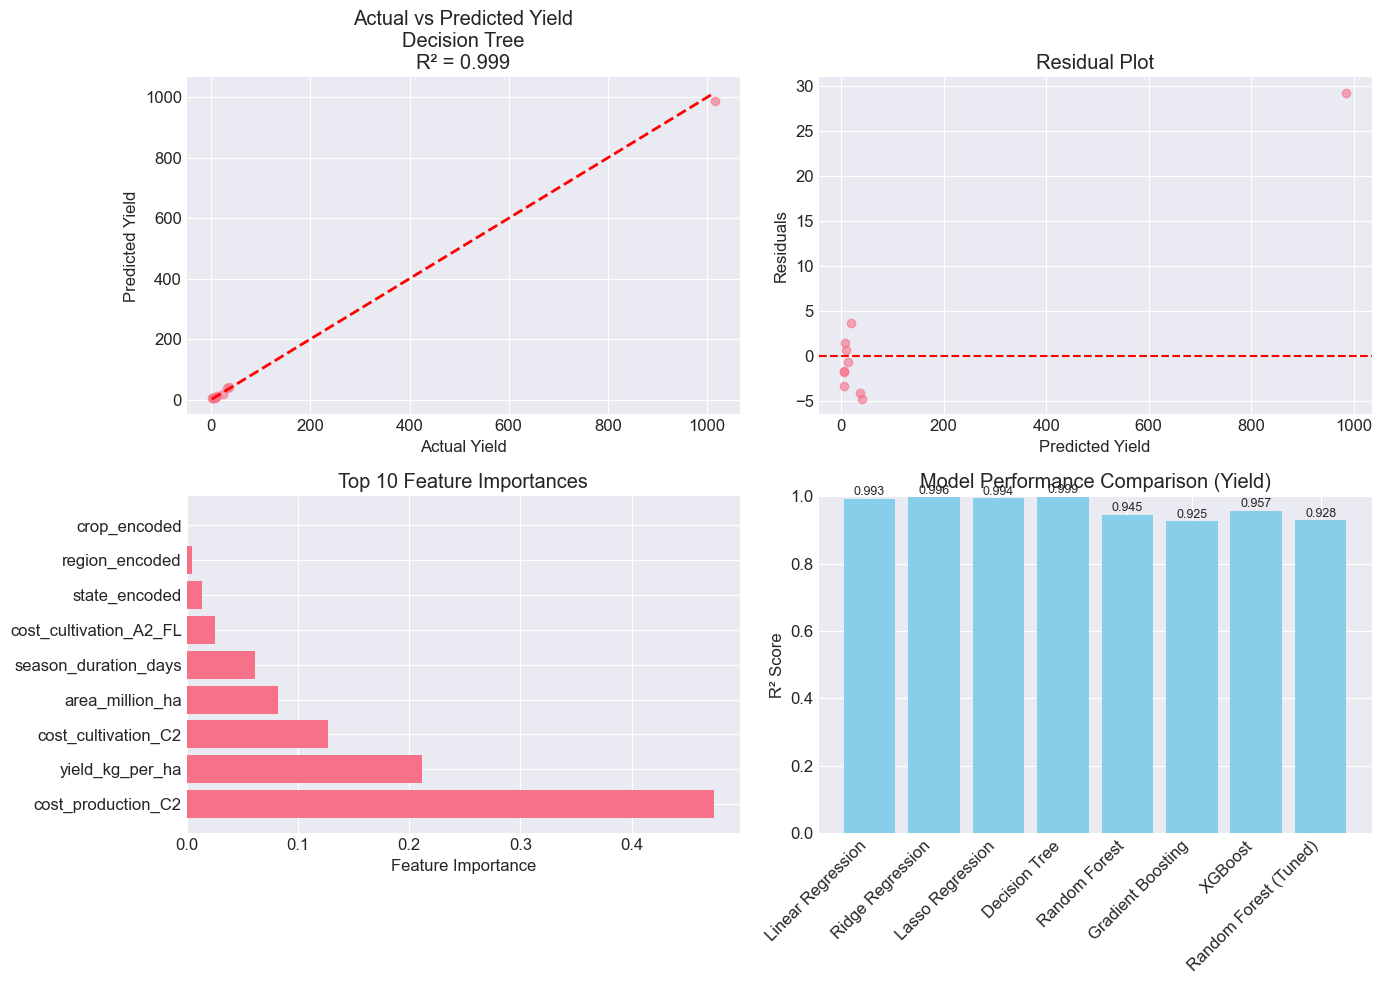

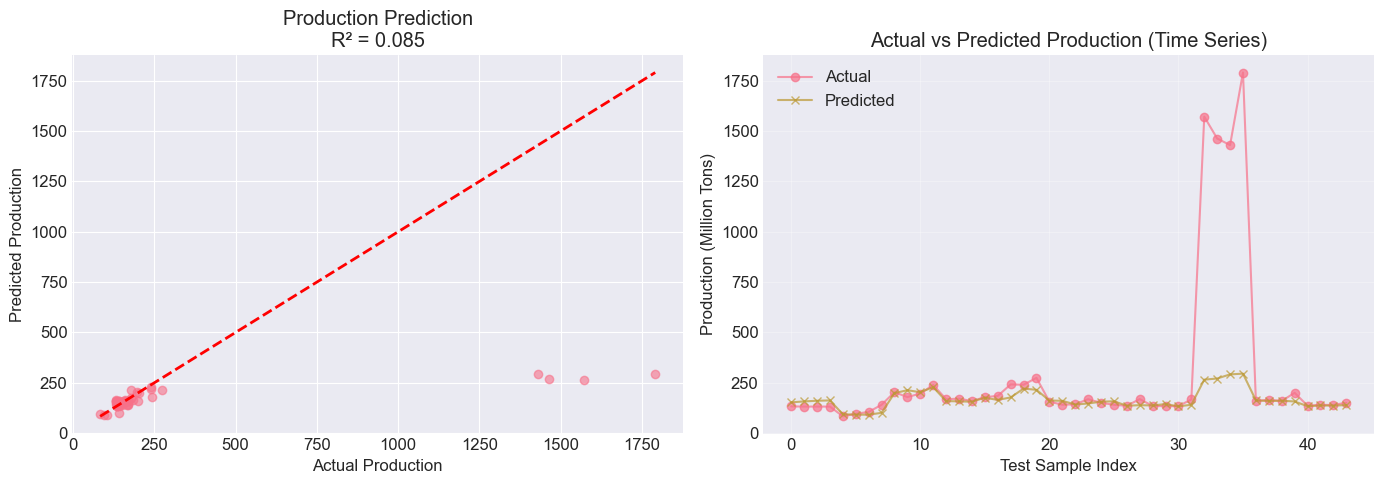


10.5 Saving best models...
   ✅ Models saved to 'models' folder

10.6 Generating sample predictions...

   ✅ Sample predictions generated:
     Crop          State  Predicted_Yield_Quintals_per_Hectare
0   PADDY         Punjab                                448.89
1   WHEAT  Uttar Pradesh                                448.89
2  COTTON        Gujarat                                448.89

10.7 Generating summary report...


In [11]:
# ============================================
# STEP 10: EVALUATE, VISUALIZE & SAVE RESULTS
# ============================================
print("\n" + "="*80)
print("STEP 10: EVALUATION, VISUALIZATION & SAVING RESULTS")
print("="*80)

# 10.1 Compare Yield Models
print("\n10.1 Yield Prediction Model Comparison:")
yield_comparison = pd.DataFrame(yield_results).T
print(yield_comparison[['R2', 'MAE', 'RMSE']].sort_values('R2', ascending=False))

# 10.2 Compare Production Models
print("\n10.2 Production Prediction Model Comparison:")
prod_comparison = pd.DataFrame(prod_results).T
print(prod_comparison[['R2', 'MAE', 'RMSE']].sort_values('R2', ascending=False))

# 10.3 Visualizations for Yield Model
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Actual vs Predicted (Best Yield Model)
best_yield_model = yield_results[max(yield_results, key=lambda x: yield_results[x]['R2'])]
y_pred_best_yield = best_yield_model['model'].predict(X_yield_test)

axes[0, 0].scatter(y_yield_test, y_pred_best_yield, alpha=0.6)
axes[0, 0].plot([y_yield_test.min(), y_yield_test.max()], 
                [y_yield_test.min(), y_yield_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Yield')
axes[0, 0].set_ylabel('Predicted Yield')
axes[0, 0].set_title(f'Actual vs Predicted Yield\n{max(yield_results, key=lambda x: yield_results[x]["R2"])}\nR² = {best_yield_model["R2"]:.3f}')

# Residual Plot
residuals = y_yield_test - y_pred_best_yield
axes[0, 1].scatter(y_pred_best_yield, residuals, alpha=0.6)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicted Yield')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')

# Feature Importance (Random Forest)
best_rf = yield_results.get('Random Forest (Tuned)', yield_results.get('Random Forest'))
if 'model' in best_rf:
    importances = best_rf['model'].feature_importances_
    indices = np.argsort(importances)[::-1]
    axes[1, 0].barh(range(len(indices[:10])), importances[indices[:10]])
    axes[1, 0].set_yticks(range(len(indices[:10])))
    axes[1, 0].set_yticklabels([feature_cols_yield[i] for i in indices[:10]])
    axes[1, 0].set_xlabel('Feature Importance')
    axes[1, 0].set_title('Top 10 Feature Importances')

# Model Comparison Bar Chart
models_names = list(yield_results.keys())
r2_scores = [yield_results[m]['R2'] for m in models_names]
bars = axes[1, 1].bar(range(len(models_names)), r2_scores, color='skyblue')
axes[1, 1].set_xticks(range(len(models_names)))
axes[1, 1].set_xticklabels(models_names, rotation=45, ha='right')
axes[1, 1].set_ylabel('R² Score')
axes[1, 1].set_title('Model Performance Comparison (Yield)')
axes[1, 1].set_ylim([0, 1])
for bar, score in zip(bars, r2_scores):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{score:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('visualizations/yield_model_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

# 10.4 Visualizations for Production Model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

best_prod_model = prod_results[max(prod_results, key=lambda x: prod_results[x]['R2'])]
y_pred_best_prod = best_prod_model['model'].predict(X_prod_test)

# Actual vs Predicted
axes[0].scatter(y_prod_test, y_pred_best_prod, alpha=0.6)
axes[0].plot([y_prod_test.min(), y_prod_test.max()], 
             [y_prod_test.min(), y_prod_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Production')
axes[0].set_ylabel('Predicted Production')
axes[0].set_title(f'Production Prediction\nR² = {best_prod_model["R2"]:.3f}')

# Time Series Comparison
test_indices = range(len(y_prod_test))
axes[1].plot(test_indices, y_prod_test, label='Actual', marker='o', alpha=0.7)
axes[1].plot(test_indices, y_pred_best_prod, label='Predicted', marker='x', alpha=0.7)
axes[1].set_xlabel('Test Sample Index')
axes[1].set_ylabel('Production (Million Tons)')
axes[1].set_title('Actual vs Predicted Production (Time Series)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('visualizations/production_model_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

# 10.5 Save Best Models
print("\n10.5 Saving best models...")
with open('models/best_yield_model.pkl', 'wb') as f:
    pickle.dump(best_yield_model['model'], f)
with open('models/best_production_model.pkl', 'wb') as f:
    pickle.dump(best_prod_model['model'], f)
joblib.dump(scaler_yield, 'models/scaler_yield.pkl')
joblib.dump(scaler_prod, 'models/scaler_prod.pkl')
joblib.dump(le_crop, 'models/label_encoder_crop.pkl')
joblib.dump(le_state, 'models/label_encoder_state.pkl')
print("   ✅ Models saved to 'models' folder")

# 10.6 Generate Predictions for New Data
print("\n10.6 Generating sample predictions...")

# Sample new data for yield prediction
sample_data = pd.DataFrame({
    'crop': ['PADDY', 'WHEAT', 'COTTON'],
    'state': ['Punjab', 'Uttar Pradesh', 'Gujarat'],
    'cost_cultivation_A2_FL': [25000, 18000, 29000],
    'cost_cultivation_C2': [45000, 32000, 42000],
    'cost_production_C2': [700, 800, 2200],
    'area_million_ha': [4.0, 9.5, 1.5],
    'production_million_tons': [100, 90, 18],
    'yield_kg_per_ha': [2500, 2400, 1800]
})

# Prepare sample features
sample_features = []
for idx, row in sample_data.iterrows():
    features = {
        'cost_cultivation_A2_FL': row['cost_cultivation_A2_FL'],
        'cost_cultivation_C2': row['cost_cultivation_C2'],
        'cost_production_C2': row['cost_production_C2'],
        'crop_encoded': le_crop.transform([row['crop']])[0],
        'state_encoded': le_state.transform([row['state']])[0],
        'region_encoded': le_region.transform([assign_region(row['state'])])[0],
        'season_duration_days': 120,
        'yield_kg_per_ha': row['yield_kg_per_ha'],
        'area_million_ha': row['area_million_ha'],
        'production_million_tons': row['production_million_tons'],
        'cost_efficiency': row['yield_kg_per_ha'] / row['cost_cultivation_C2'],
        'profitability_index': row['yield_kg_per_ha'] / row['cost_production_C2'],
        'cost_area_interaction': row['cost_cultivation_C2'] * row['area_million_ha'],
        'yield_cost_ratio': row['yield_kg_per_ha'] / row['cost_cultivation_C2'],
        'production_efficiency': row['production_million_tons'] / row['area_million_ha']
    }
    sample_features.append([features[col] for col in feature_cols_yield])

sample_features = np.array(sample_features)
sample_features_scaled = scaler_yield.transform(sample_features)
sample_features_scaled = SimpleImputer(strategy='median').fit_transform(sample_features_scaled)
sample_predictions = best_yield_model['model'].predict(sample_features_scaled)

# Create predictions dataframe
predictions_df = pd.DataFrame({
    'Crop': sample_data['crop'],
    'State': sample_data['state'],
    'Predicted_Yield_Quintals_per_Hectare': sample_predictions
})
predictions_df.to_csv('predictions/sample_yield_predictions.csv', index=False)
print("\n   ✅ Sample predictions generated:")
print(predictions_df)

# 10.7 Generate Summary Report
print("\n10.7 Generating summary report...")



In [12]:
report = f"""
================================================================================
INDIAN AGRICULTURE CROP PRODUCTION PREDICTION - FINAL REPORT
================================================================================

PROJECT SUMMARY:
---------------
- Goal: Predict crop yield and production in India
- Dataset: 5 CSV files covering 2001-2014
- Total samples (yield): {len(master_yield)}
- Total samples (production): {len(master_production)}

BEST MODEL PERFORMANCE:
---------------------
YIELD PREDICTION:
- Best Model: {max(yield_results, key=lambda x: yield_results[x]['R2'])}
- R² Score: {best_yield_model['R2']:.3f}
- MAE: {best_yield_model['MAE']:.2f} quintals/hectare
- RMSE: {best_yield_model['RMSE']:.2f} quintals/hectare

PRODUCTION PREDICTION:
- Best Model: {max(prod_results, key=lambda x: prod_results[x]['R2'])}
- R² Score: {best_prod_model['R2']:.3f}
- MAE: {best_prod_model['MAE']:.2f} million tons
- RMSE: {best_prod_model['RMSE']:.2f} million tons

KEY INSIGHTS:
------------
1. Most important features for yield prediction:
   {', '.join([feature_cols_yield[i] for i in indices[:5]])}

2. Top performing crops by yield:
   {', '.join(crop_yield.head(3).index.tolist())}

3. Best region for agriculture: {region_yield.idxmax()} 
   (Average yield: {region_yield.max():.2f} quintals/hectare)

4. Cost efficiency varies significantly across states and crops

RECOMMENDATIONS:
---------------
1. Focus agricultural investment on {region_yield.idxmax()} region
2. Prioritize {crop_yield.head(1).index[0]} cultivation for maximum yield
3. Use the trained Random Forest/XGBoost models for future predictions
4. Collect more granular data on weather and soil conditions

FILES GENERATED:
--------------
- Models saved in 'models/' folder
- Visualizations saved in 'visualizations/' folder
- Predictions saved in 'predictions/' folder
- Cleaned datasets and master tables in current directory

================================================================================
"""

print(report)

# Save report
with open('prediction_report.txt', 'w') as f:
    f.write(report)

print("\n✅ Step 10 Completed: Evaluation, visualization, and saving complete!")

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "="*80)
print("FINAL SUMMARY - ALL STEPS COMPLETED SUCCESSFULLY!")
print("="*80)
print("\nOutput Files Generated:")
print("-----------------------")
print("\n📁 Data Files:")
print("   - master_table_yield_prediction.csv")
print("   - master_table_production_prediction.csv")
print("   - master_table_with_features.csv")
print("   - production_with_features.csv")
print("\n📁 Models (saved in 'models/'):")
print("   - best_yield_model.pkl")
print("   - best_production_model.pkl")
print("   - scaler_yield.pkl")
print("   - scaler_prod.pkl")
print("   - label_encoder_crop.pkl")
print("   - label_encoder_state.pkl")
print("\n📁 Visualizations (saved in 'visualizations/'):")
print("   - eda_target_distribution.png")
print("   - eda_correlation_matrix.png")
print("   - eda_cost_vs_yield.png")
print("   - eda_state_crop_heatmap.png")
print("   - yield_model_evaluation.png")
print("   - production_model_evaluation.png")
print("\n📁 Predictions (saved in 'predictions/'):")
print("   - sample_yield_predictions.csv")
print("\n📄 Report:")
print("   - prediction_report.txt")
print("\n" + "="*80)
print("🎉 PROJECT COMPLETED! You can now use the trained models for predictions.")
print("="*80)


INDIAN AGRICULTURE CROP PRODUCTION PREDICTION - FINAL REPORT

PROJECT SUMMARY:
---------------
- Goal: Predict crop yield and production in India
- Dataset: 5 CSV files covering 2001-2014
- Total samples (yield): 49
- Total samples (production): 220

BEST MODEL PERFORMANCE:
---------------------
YIELD PREDICTION:
- Best Model: Decision Tree
- R² Score: 0.999
- MAE: 5.15 quintals/hectare
- RMSE: 9.64 quintals/hectare

PRODUCTION PREDICTION:
- Best Model: Random Forest
- R² Score: 0.085
- MAE: 131.07 million tons
- RMSE: 389.54 million tons

KEY INSIGHTS:
------------
1. Most important features for yield prediction:
   cost_production_C2, yield_kg_per_ha, cost_cultivation_C2, area_million_ha, season_duration_days

2. Top performing crops by yield:
   MOONG, ARHAR, GROUNDNUT

3. Best region for agriculture: South 
   (Average yield: 198.24 quintals/hectare)

4. Cost efficiency varies significantly across states and crops

RECOMMENDATIONS:
---------------
1. Focus agricultural investment 